Epoch 1/10, Train Loss: 1.3026, Val Loss: 0.9917, Train Acc: 0.5256, Val Acc: 0.6512
Epoch 2/10, Train Loss: 0.9072, Val Loss: 0.8139, Train Acc: 0.6830, Val Acc: 0.7122
Epoch 3/10, Train Loss: 0.7575, Val Loss: 0.7108, Train Acc: 0.7380, Val Acc: 0.7565
Epoch 4/10, Train Loss: 0.6762, Val Loss: 0.6909, Train Acc: 0.7668, Val Acc: 0.7741
Epoch 5/10, Train Loss: 0.6162, Val Loss: 0.5778, Train Acc: 0.7870, Val Acc: 0.8122
Epoch 6/10, Train Loss: 0.5741, Val Loss: 0.5545, Train Acc: 0.8024, Val Acc: 0.8095
Epoch 7/10, Train Loss: 0.5402, Val Loss: 0.5638, Train Acc: 0.8154, Val Acc: 0.8118
Epoch 8/10, Train Loss: 0.5132, Val Loss: 0.5148, Train Acc: 0.8223, Val Acc: 0.8272
Epoch 9/10, Train Loss: 0.4914, Val Loss: 0.5175, Train Acc: 0.8328, Val Acc: 0.8244
Epoch 10/10, Train Loss: 0.4715, Val Loss: 0.4738, Train Acc: 0.8381, Val Acc: 0.8406
Accuracy: 0.8406, Precision: 0.8406, Recall: 0.8406


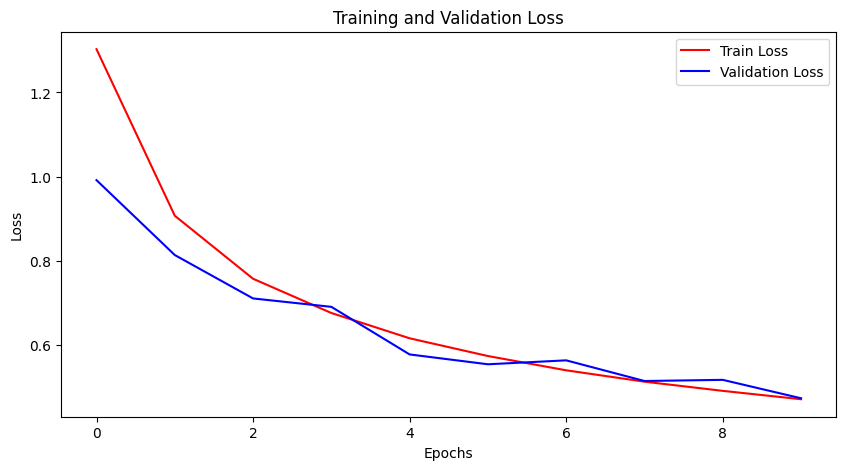

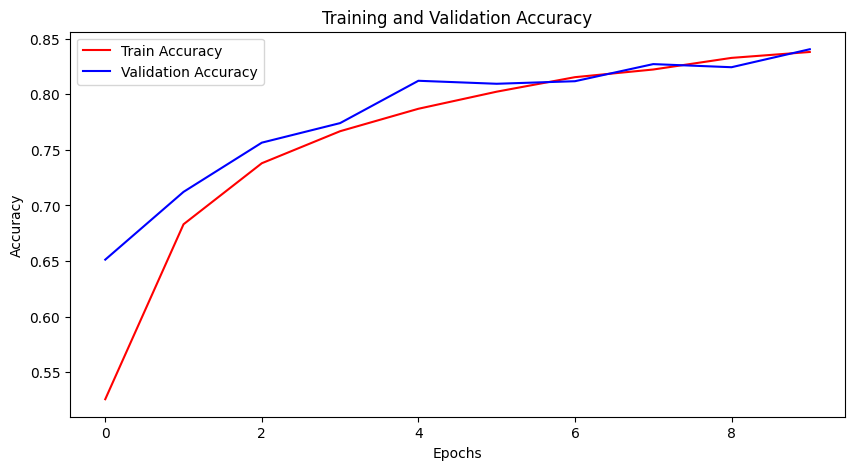

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define MobileNetV2
class MobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super(MobileNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, groups=64),  # Added padding
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, groups=128),  # Added padding
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, groups=256),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, groups=512),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1 ,1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 1 * 1 ,1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(1024 ,num_classes)
        )

    def forward(self ,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# calculate accuracy
def calculate_accuracy(outputs ,labels):
    _, preds = torch.max(outputs ,1)
    return (preds == labels).sum().item() / labels.size(0)

def train_model_with_accuracy(model ,criterion ,optimizer ,epochs=10):
    train_losses ,val_losses = [], []
    train_accuracies ,val_accuracies = [], []

    for epoch in range(epochs):
        # Training
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0

        for images ,labels in train_loader:
            images ,labels = images.to(device) ,labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs ,labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            running_corrects += calculate_accuracy(outputs ,labels) * labels.size(0)
            total_samples += labels.size(0)

        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(running_corrects / total_samples)

        # Validation
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_total_samples = 0

        with torch.no_grad():
           for images ,labels in test_loader:
               images ,labels = images.to(device) ,labels.to(device)
               outputs = model(images)
               loss = criterion(outputs ,labels)
               val_loss += loss.item()
               val_corrects += calculate_accuracy(outputs ,labels) * labels.size(0)
               val_total_samples += labels.size(0)

        val_losses.append(val_loss / len(test_loader))
        val_accuracies.append(val_corrects / val_total_samples)

        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, "
              f"Train Acc: {train_accuracies[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    return train_losses ,val_losses ,train_accuracies ,val_accuracies

def evaluate_model(model):
    model.eval()
    y_true ,y_pred = [], []
    with torch.no_grad():
       for images ,labels in test_loader:
           images ,labels = images.to(device) ,labels.to(device)
           outputs = model(images)
           _, preds = torch.max(outputs ,1)
           y_true.extend(labels.cpu().numpy())
           y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true ,y_pred)
    precision = precision_score(y_true ,y_pred ,average='macro')
    recall = recall_score(y_true ,y_pred ,average='macro')

    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    return acc ,precision ,recall

#  MobileNet model
mobilenet_model = MobileNet().to(device)

#  loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet_model.parameters() ,lr=0.001)

# Train the model and get accuracy/loss data
mobilenet_train_losses ,mobilenet_val_losses ,mobilenet_train_accs ,mobilenet_val_accs = train_model_with_accuracy(
   mobilenet_model ,criterion ,optimizer ,epochs=10)

# Evaluate the model
evaluate_model(mobilenet_model)

# Save the model
torch.save(mobilenet_model.state_dict() ,"mobilenet_cifar10.pth")

# Plot training and validation losses
plt.figure(figsize=(10 ,5))
plt.plot(mobilenet_train_losses ,'r-', label='Train Loss')
plt.plot(mobilenet_val_losses ,'b-', label='Validation Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(10 ,5))
plt.plot(mobilenet_train_accs ,'r-', label='Train Accuracy')
plt.plot(mobilenet_val_accs ,'b-', label='Validation Accuracy')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


def load_model(filepath):
    model = MobileNet().to(device)
    model.load_state_dict(torch.load(filepath,map_location=device))
    model.eval()
    return model

# Load saved model
mobilenet_loaded = load_model("mobilenet_cifar10.pth")
